## Netflix Data Analysis

## Project Overview

Exploratory Data Analysis of Netflix Movies  using Python.

## Objectives

- Analyze the Netflix movie dataset using Python.
- Identify the most frequent movie genres.
- Analyze vote averages and ratings.
- Identify the most and least popular movies and their genres.
- Analyze movie release-year trends.
- Generate meaningful insights using data analysis and visualization.


### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd            #importing lib pandas for data cleaning,numpy for mathematics ,matplot and seaborn for grap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
df= pd.read_csv("mymoviedb.csv",lineterminator='\n')     #colab will read the file

In [12]:
df.head()    # to se first 5 rows

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2447 entries, 0 to 2446
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       2447 non-null   object 
 1   Title              2447 non-null   object 
 2   Overview           2447 non-null   object 
 3   Popularity         2447 non-null   float64
 4   Vote_Count         2447 non-null   int64  
 5   Vote_Average       2447 non-null   float64
 6   Original_Language  2447 non-null   object 
 7   Genre              2447 non-null   object 
 8   Poster_Url         2447 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 172.2+ KB


In [14]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,2447.000000,2447.000000,2447.000000
mean,101.913947,3146.480180,6.625868
std,206.080884,4313.779159,1.102282
min,35.266000,0.000000,0.000000
25%,43.347500,227.000000,6.100000
50%,57.705000,1298.000000,6.700000
75%,92.618000,4559.000000,7.300000
max,5083.954000,31077.000000,9.100000


Release_date col need to change into date time and to extract only year value.
overview ,original_language and poster_url do not required for analysis so they are removed .
there is outliers in popularity col .
vote_avg better to be categorical .









In [18]:
df['Release_Date']= pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2447 entries, 0 to 2446
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       2447 non-null   datetime64[ns]
 1   Title              2447 non-null   object        
 2   Overview           2447 non-null   object        
 3   Popularity         2447 non-null   float64       
 4   Vote_Count         2447 non-null   int64         
 5   Vote_Average       2447 non-null   float64       
 6   Original_Language  2447 non-null   object        
 7   Genre              2447 non-null   object        
 8   Poster_Url         2447 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 172.2+ KB


In [20]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [21]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [22]:
#dropping columns
cols = ['Overview','Original_Language','Poster_Url']
df.drop(cols,axis=1,inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


Categorizing Vote_Average column
we will cut the vote average values and make 4 categories :popular,average, below_avg, not_popular to desc it more using catigorizies col function

In [32]:
def categorize_col(df,col,labels):
  edges = [df[col].min(),
           df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max'],
           ]
  df[col]=pd.cut(df[col],edges,labels=labels, duplicates ='drop')
  return df                                                             # here function is created

In [33]:
labels = ['not_popular', 'below_avg','average','popular']
categorize_col(df,'Vote_Average', labels)
df['Vote_Average'].unique()      #here function is called

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [34]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [35]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
not_popular,622
below_avg,621
average,601
popular,581


In [36]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


we will split genres into a list and then explode our dataframe to have on;y one genre per row for each movies

In [37]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [38]:
#casting col into category
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [40]:
df.nunique()

,0
Release_Date,74
Title,2378
Popularity,2379
Vote_Count,1835
Vote_Average,4
Genre,19


DATA **VISUALIZATION**

**What is the most frequent genre of movie released on Netflix**

In [41]:
df['Genre'].describe()


,Genre
count,6713
unique,19
top,Action
freq,857


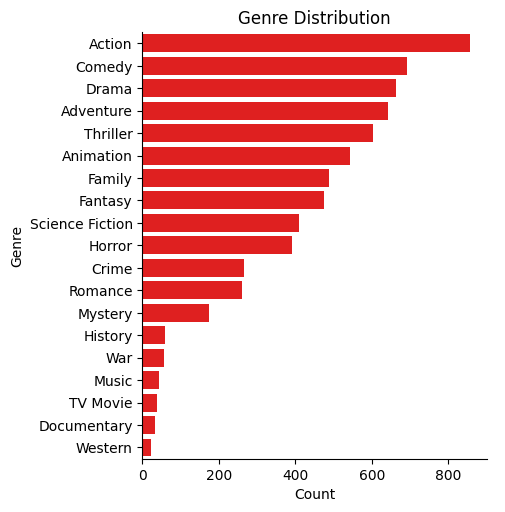

In [42]:
sns.catplot(y = 'Genre',data= df, kind='count',order=df['Genre'].value_counts().index, color='red')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.title('Genre Distribution')
plt.show()

**Which has the highest votes in vote avg column?**

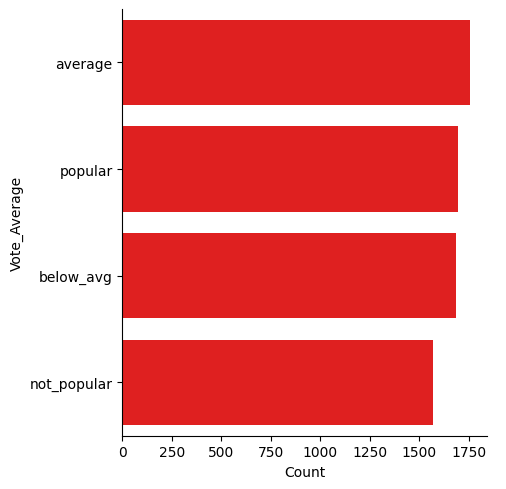

In [43]:
sns.catplot(y = 'Vote_Average',data= df, kind='count',order=df['Vote_Average'].value_counts().index, color='red')
plt.xlabel('Count')
plt.ylabel('Vote_Average')
plt.show()

**What movies  got the highest popularity ?what's its genre?**

In [44]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


**What movies got the lowest popularity?**

In [45]:
df[df['Popularity']==df['Popularity'].min()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
6709,1991,An American Tail: Fievel Goes West,35.266,588,below_avg,Adventure
6710,1991,An American Tail: Fievel Goes West,35.266,588,below_avg,Animation
6711,1991,An American Tail: Fievel Goes West,35.266,588,below_avg,Family
6712,1991,An American Tail: Fievel Goes West,35.266,588,below_avg,Western


**which year have the most filmmed movies?**

In [52]:
year = df['Release_Date'].value_counts().idxmax()
count = df['Release_Date'].value_counts().max()

print("Year with the most movies:", year)
print("Number of movies:", count)

Year with the most movies: 2021
Number of movies: 1093


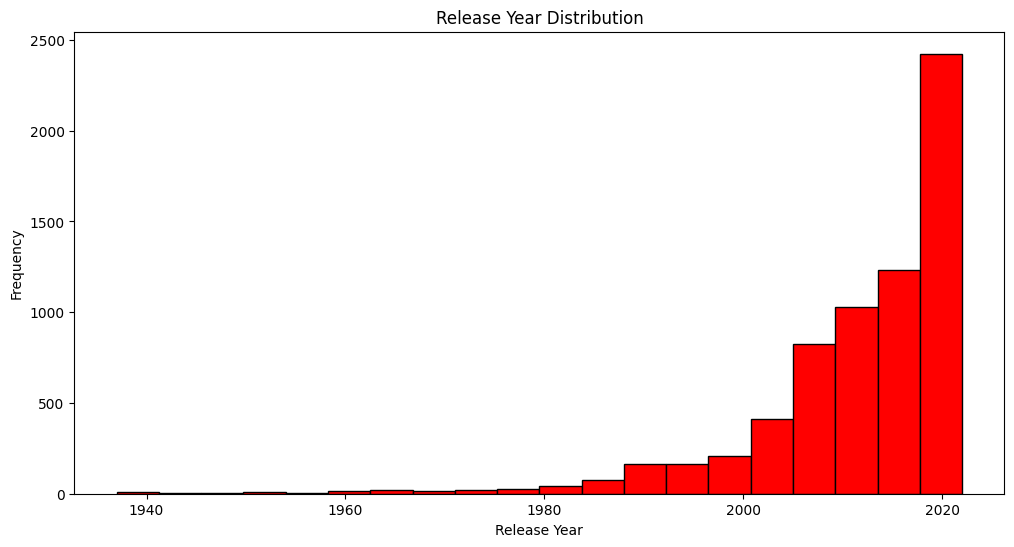

In [54]:
plt.figure(figsize=(12, 6))

plt.hist(df['Release_Date'], bins=20, color='red', edgecolor='black')

plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

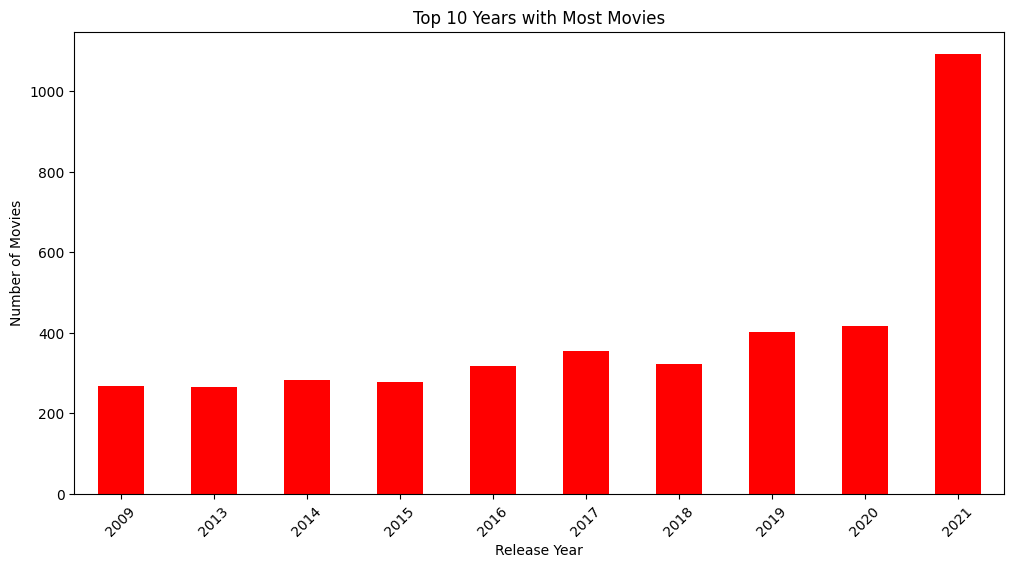

In [55]:
plt.figure(figsize=(12,6))

df['Release_Date'].value_counts().head(10).sort_index().plot(
    kind='bar',
    color='red'
)

plt.title('Top 10 Years with Most Movies')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)

plt.show()

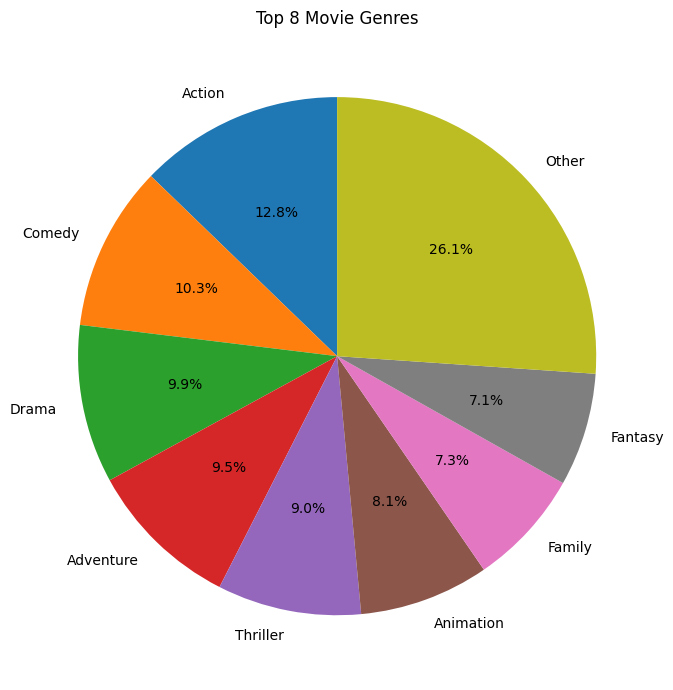

In [58]:
genre_counts = df['Genre'].value_counts()

# Keep top 8 genres
top_genres = genre_counts.head(8)

# Combine remaining genres
other = genre_counts.iloc[8:].sum()

top_genres['Other'] = other

plt.figure(figsize=(9, 7))

plt.pie(
    top_genres,
    labels=top_genres.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 8 Movie Genres')
plt.tight_layout()
plt.show()

**Movies Released Over Years**

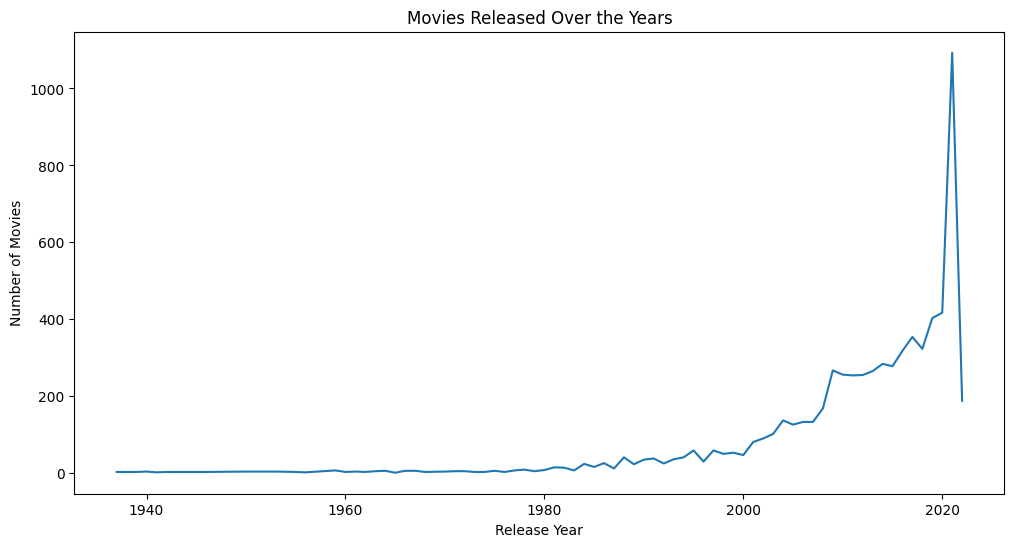

In [59]:
year_count = df['Release_Date'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(year_count.index, year_count.values)

plt.title('Movies Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')

plt.show()